### Задание:
**Задача 1: EDA таблицы payments**

Изучите таблицу payments и проведите разведочный анализ данных. Для этого нужно ответить на вопросы
+ определите сколько в таблице строк  и столбцов
+ выведите среднее, медиану, минимум, максимум и стандартное отклонение для колонки sum_payment
+ выведите количество нуллов. Можем ли мы заполнить нуллы значениями
+ выведите количество выбросов. Очистите данные от выбросов
+ постройте график с распределением sum_payment (sns.histplot)

**Задача 2**
Агрегируйте данные по пользователю и месяцу

**Задача 3**
Рассчитайте выручку и количество тренировок в динамике по месяцам. Постройте графики

**Задача 4** 
Рассчитайте LT и LTR. Подумайте, должны ли мы учитывать при расчете все когорты пользователей

**Задача 5**
Оцените эффект от маркетинговой акции для выручки и для прибыли (при условии, что переменные косты на 1 занятие равны 800 руб. для индивидуальной тренировки и 200 руб. для групповой)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
payments = pd.read_csv('payments.csv')
payments.head()

,id_user,training_type,sum_payment,date
0,1000,indiv,1800.0,2023-03-04
1,1000,indiv,1800.0,2023-03-21
2,1000,indiv,1800.0,2023-04-03
3,1000,indiv,1800.0,2023-04-12
4,1000,indiv,1800.0,2023-04-20


### Задача 1. EDA

In [10]:
payments.shape

(35775, 4)

In [48]:
payments.dtypes

id_user            int64
training_type     object
sum_payment      float64
date              object
dtype: object

In [8]:
payments.isnull().sum()

id_user            0
training_type      0
sum_payment      715
date             357
dtype: int64

In [10]:
payments.loc[payments['sum_payment'].isnull()]

,id_user,training_type,sum_payment,date
18,1000,indiv,NaN,2023-08-09
32,1000,indiv,NaN,2023-12-21
54,1001,group,NaN,2023-02-07
89,1001,indiv,NaN,2023-04-30
118,1001,group,NaN,2023-07-22
...,...,...,...,...
35488,1987,indiv,NaN,2023-06-01
35520,1988,indiv,NaN,2023-03-16
35643,1993,group,NaN,2023-08-06
35691,1995,group,NaN,2023-11-23


In [12]:
payments.loc[(payments['sum_payment'].isnull()) & (payments['training_type'] == 'group'), 'sum_payment'] = 800
payments.loc[(payments['sum_payment'].isnull()) & (payments['training_type'] == 'indiv'), 'sum_payment'] = 1800

In [14]:
payments['date'] = pd.to_datetime(payments['date'], errors = 'coerce')
payments.loc[(payments['sum_payment'].isnull()) & (payments['training_type'] == 'indiv') & (payments['date'].dt.month == 5), 'sum_payment'] = 1600
payments.isnull().sum()

id_user            0
training_type      0
sum_payment        0
date             357
dtype: int64

In [16]:
payments = payments[~payments['date'].isnull()]

In [18]:
payments.isnull().sum()

id_user          0
training_type    0
sum_payment      0
date             0
dtype: int64

In [20]:
avg_pay = payments['sum_payment'].mean()
print(f"Среднее арифметическое платежей: {avg_pay}")
med_pay = payments['sum_payment'].median()
print(f"Медиана платежей: {med_pay}")
max_pay = payments['sum_payment'].max()
min_pay = payments['sum_payment'].min()
print(f"Максимальное значение: {max_pay} и минимальное значение платажей: {min_pay}")
std_pay = payments['sum_payment'].std()
print(f"Стандартное отклонение: {std_pay}")

Среднее арифметическое платежей: 1116.3984414704387
Медиана платежей: 800.0
Максимальное значение: 18000.0 и минимальное значение платажей: 800.0
Стандартное отклонение: 874.5293190744394


In [22]:
payments['sum_payment'].describe()

count    35418.000000
mean      1116.398441
std        874.529319
min        800.000000
25%        800.000000
50%        800.000000
75%       1600.000000
max      18000.000000
Name: sum_payment, dtype: float64

In [24]:
payments['training_type'].value_counts(normalize = True)

training_type
group    0.729318
indiv    0.270682
Name: proportion, dtype: float64

<Axes: ylabel='sum_payment'>

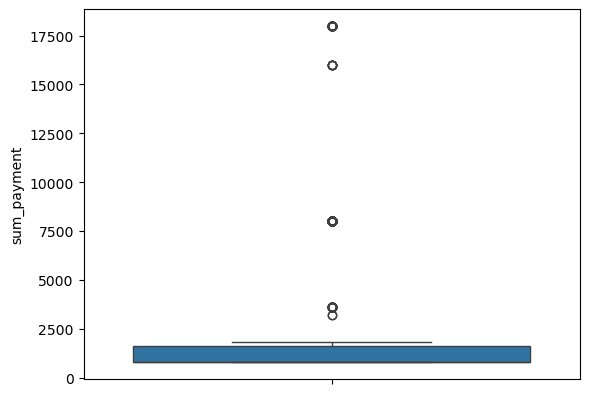

In [90]:
sns.boxplot(payments['sum_payment'])

In [26]:
Q1 = np.percentile(payments['sum_payment'], 25)
Q3 = np.percentile(payments['sum_payment'], 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print (lower_bound, upper_bound)

-400.0 2800.0


In [28]:
payments_clean = payments.loc[payments['sum_payment'] < upper_bound].copy()
payments_clean.head()

,id_user,training_type,sum_payment,date
0,1000,indiv,1800.0,2023-03-04
1,1000,indiv,1800.0,2023-03-21
2,1000,indiv,1800.0,2023-04-03
3,1000,indiv,1800.0,2023-04-12
4,1000,indiv,1800.0,2023-04-20


### Задача 2. Агрегация данных

In [30]:
payments_clean['mon'] = payments_clean['date'].dt.strftime('%Y-%m')
payments_clean.head()

,id_user,training_type,sum_payment,date,mon
0,1000,indiv,1800.0,2023-03-04,2023-03
1,1000,indiv,1800.0,2023-03-21,2023-03
2,1000,indiv,1800.0,2023-04-03,2023-04
3,1000,indiv,1800.0,2023-04-12,2023-04
4,1000,indiv,1800.0,2023-04-20,2023-04


In [32]:
pivot_pay = pd.pivot_table(payments_clean, index = ['id_user', 'mon'],\
columns = 'training_type', \
values = 'sum_payment', \
aggfunc = ['count', 'sum'], 
fill_value = 0).reset_index()
pivot_pay.head()

id_user      mon count         sum        
training_type                  group indiv group   indiv
0                1000  2023-03     0     2   0.0  3600.0
1                1000  2023-04     0     4   0.0  7200.0
2                1000  2023-05     0     4   0.0  6400.0
3                1000  2023-06     0     2   0.0  3600.0
4                1000  2023-07     0     4   0.0  7200.0

In [34]:
pivot_pay.columns = ['id_user', 'mon', 'cnt_group', 'cnt_indiv', 'sum_group', 'sum_indiv']
pivot_pay['cnt_total'] = pivot_pay['cnt_group'] + pivot_pay['cnt_indiv']
pivot_pay['sum_total'] = pivot_pay['sum_group'] + pivot_pay['sum_indiv']
pivot_pay.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total
0,1000,2023-03,0,2,0.0,3600.0,2,3600.0
1,1000,2023-04,0,4,0.0,7200.0,4,7200.0
2,1000,2023-05,0,4,0.0,6400.0,4,6400.0
3,1000,2023-06,0,2,0.0,3600.0,2,3600.0
4,1000,2023-07,0,4,0.0,7200.0,4,7200.0


In [36]:
pivot_pay['sum_total'].mean()

7088.72095220102

### Задача 3. Анализ выручки и количества тренировок

In [38]:
pay_gr = pivot_pay.groupby('mon')[['cnt_group', 'cnt_indiv', 'cnt_total','sum_group', 'sum_indiv', 'sum_total']].sum().reset_index()
pay_gr.head()

,mon,cnt_group,cnt_indiv,cnt_total,sum_group,sum_indiv,sum_total
0,2023-01,1787,856,2643,1437600.0,1540800.0,2978400.0
1,2023-02,1804,920,2724,1447200.0,1656000.0,3103200.0
2,2023-03,1789,872,2661,1439200.0,1569600.0,3008800.0
3,2023-04,1955,720,2675,1572800.0,1296000.0,2868800.0
4,2023-05,1541,1320,2861,1242400.0,2116400.0,3358800.0


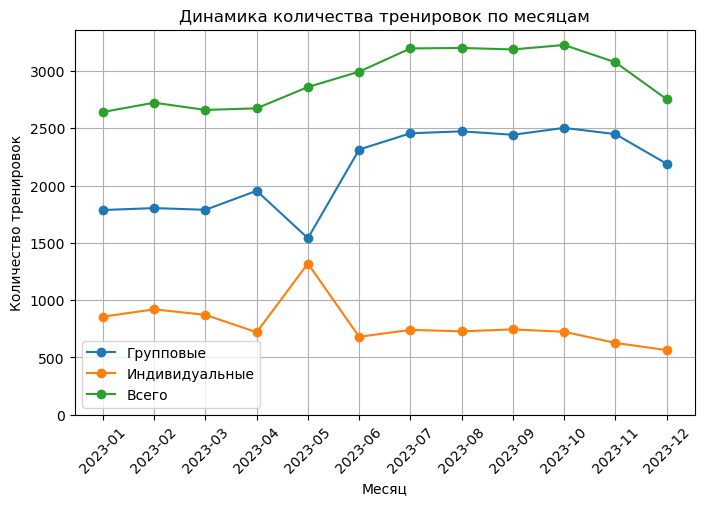

In [48]:
plt.figure(figsize=(8, 5)) # задаем размер графика
plt.plot(pay_gr['mon'], pay_gr['cnt_group'], marker='o', label='Групповые') # рисуем линию для групповых тренировок
plt.plot(pay_gr['mon'], pay_gr['cnt_indiv'], marker='o', label='Индивидуальные') #рисуем линию для инд. тренировок
plt.plot(pay_gr['mon'], pay_gr['cnt_total'], marker='o', label='Всего') #рисуем линию для кол-ва всех тренировок
plt.xlabel('Месяц') # подписываем ось х
plt.ylabel('Количество тренировок') # подписываем ось y
plt.title('Динамика количества тренировок по месяцам') #подписываем график
plt.legend() #добавляем легенду - где какая линия
plt.grid(True) # добавляем сетку
plt.ylim(bottom=0)  # начинаем ось Y с нуля
plt.xticks(rotation=45)  # поворот подписей на оси X
plt.show() # выводим график на экран

In [50]:
plt.figure(figsize=(8, 5)) # задаем размер графика
plt.plot(pay_gr['mon'], pay_gr['sum_group'], marker='o', label='Групповые') # рисуем линию для выручки по групповым тренировкам
plt.plot(pay_gr['mon'], pay_gr['sum_indiv'], marker='o', label='Индивидуальные') #рисуем линию для выручки по инд. тренировкам
plt.plot(pay_gr['mon'], pay_gr['sum_total'], marker='o', label='Всего') #рисуем линию для выручки от всех тренировок
plt.xlabel('Месяц') # подписываем ось х
plt.ylabel('Выручка') # подписываем ось y
plt.title('Динамика выручки по месяцам') #подписываем график
plt.legend() #добавляем легенду - где какая линия
plt.grid(True) # добавляем сетку
plt.ylim(bottom=0)  # начинаем ось Y с нуля
plt.xticks(rotation=45)  # поворот подписей на оси X
# plt.savefig('Revenue_monthly.png',
#             dpi=300,
#             bbox_inches='tight'
#             )

# plt.close()
plt.show() # выводим график на экран

### Задача 4. Считаем LT и LTR

In [52]:
pivot_pay['min_mon'] = pivot_pay.groupby('id_user')['mon'].transform('min')
pivot_pay['max_mon'] = pivot_pay.groupby('id_user')['mon'].transform('max')
pivot_pay.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon
0,1000,2023-03,0,2,0.0,3600.0,2,3600.0,2023-03,2023-12
1,1000,2023-04,0,4,0.0,7200.0,4,7200.0,2023-03,2023-12
2,1000,2023-05,0,4,0.0,6400.0,4,6400.0,2023-03,2023-12
3,1000,2023-06,0,2,0.0,3600.0,2,3600.0,2023-03,2023-12
4,1000,2023-07,0,4,0.0,7200.0,4,7200.0,2023-03,2023-12


In [54]:
pay_ltr = pivot_pay.groupby('id_user').agg(ltr = ('sum_total','sum')).reset_index()
print (round(pay_ltr['ltr'].mean(),2))
print (round(pay_ltr['ltr'].median(),2))

38720.95
30600.0


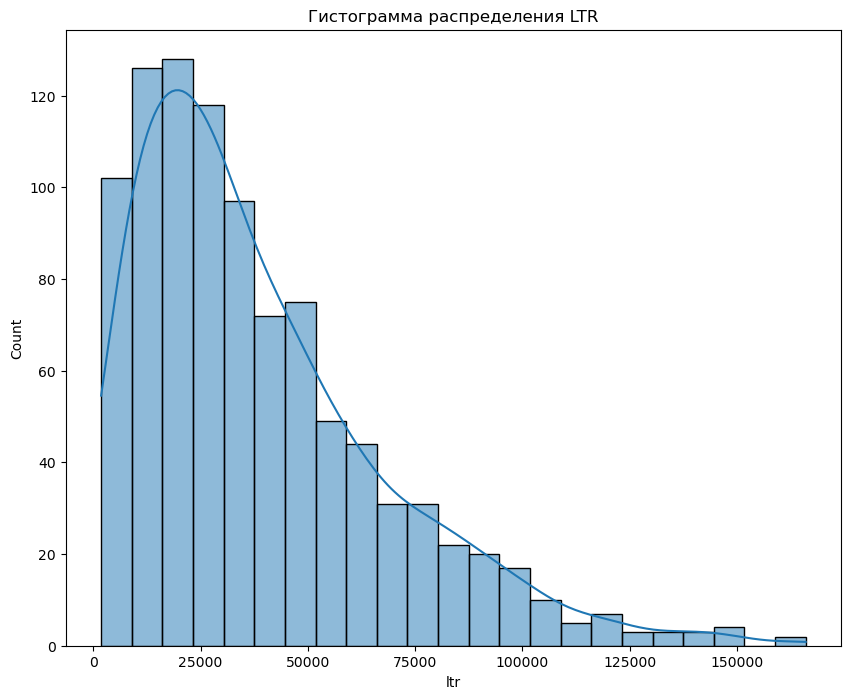

In [64]:
plt.figure(figsize=(10, 8))
sns.histplot(pay_ltr['ltr'], kde = True)
plt.title('Гистограмма распределения LTR')
# plt.savefig('LTR_distr.png',
#             dpi=300,
#             bbox_inches='tight'
#             )

# plt.close()
plt.show()

In [66]:
clean_pay = pivot_pay.loc[pivot_pay['max_mon'] != '2023-12']
print(len(pivot_pay))
print(len(clean_pay))

5293
2558


In [68]:
clean_gr = clean_pay.groupby('id_user').agg(ltr = ('sum_total','sum')).reset_index()
print (round(clean_gr['ltr'].mean(),2))
print (round(clean_gr['ltr'].median(),2))

32637.21
25600.0


In [202]:
clean_pay2 = pivot_pay.loc[pivot_pay['min_mon'].isin(['2023-01', '2023-02', '2023-03', '2023-04'])]
print(len(pivot_pay))
print(len(clean_pay2))

5293
4165


In [194]:
clean_gr2 = clean_pay2.groupby('id_user').agg(ltr = ('sum_total','sum')).reset_index()
print (round(clean_gr2['ltr'].mean(),2))
print (round(clean_gr2['ltr'].median(),2))

42423.43
35000.0


In [206]:
u_lt = clean_pay2.groupby('id_user').agg(nmon = ('id_user','count')).reset_index()
print (u_lt['nmon'].mean())
print (u_lt['nmon'].median())

6.253753753753754
7.0


### Задача 5. Анализ маркетинговой акции

In [74]:
cnt_ind_04 = pay_gr.loc[pay_gr['mon'] == '2023-04', 'cnt_indiv'].iloc[0]
cnt_ind_05 = pay_gr.loc[pay_gr['mon'] == '2023-05', 'cnt_indiv'].iloc[0]
cnt_ind_06 = pay_gr.loc[pay_gr['mon'] == '2023-06', 'cnt_indiv'].iloc[0]
cnt_gr_04 = pay_gr.loc[pay_gr['mon'] == '2023-04', 'cnt_group'].iloc[0]
cnt_gr_05 = pay_gr.loc[pay_gr['mon'] == '2023-05', 'cnt_group'].iloc[0]
cnt_gr_06 = pay_gr.loc[pay_gr['mon'] == '2023-06', 'cnt_group'].iloc[0]
cnt_ind_05

1320

In [222]:
## фактическая выручка за май
rev_fact_05 = pay_gr.loc[pay_gr['mon'] == '2023-05', 'sum_total'].iloc[0]

In [224]:
## гипотетическая выручка за май
rev_hip_05 = (cnt_ind_04 + cnt_ind_06) * 0.5 * 1800 +  (cnt_gr_04 + cnt_gr_06) * 0.5 * 800

In [226]:
print(rev_fact_05)
print(rev_hip_05)

3358800.0
2968000.0


In [228]:
print(f"Прирост выручки за счет проведения маркетинговой акции составил {rev_fact_05 - rev_hip_05} руб.")

Прирост выручки за счет проведения маркетинговой акции составил 390800.0 руб.


In [230]:
## Фактическая прибыль за май
prof_fact_05 = pay_gr.loc[pay_gr['mon'] == '2023-05', 'cnt_indiv'].iloc[0] * (1600-800) +  \
pay_gr.loc[pay_gr['mon'] == '2023-05', 'cnt_group'].iloc[0] * (800-200)

In [232]:
## Гипотетическая прибыль за май
prof_hip_05 = (cnt_ind_04 + cnt_ind_06) * 0.5 * (1800-800) +  (cnt_gr_04 + cnt_gr_06) * 0.5 * (800-200)

In [234]:
print(f"Прирост прибыли за счет проведения маркетинговой акции составил {prof_fact_05 - prof_hip_05} руб.")

Прирост прибыли за счет проведения маркетинговой акции составил -400.0 руб.
